### Imports and configuration variables

This part imports required libraries and sets the file paths and hyperparameters (sample size, random seed, output path) as simple lowercase variables so they’re easy to change in one place

In [17]:
import csv
import gzip
import json
import random
import re
import tarfile
from pathlib import Path

import pandas as pd


# file paths (adjust these)
books_csv = "books_csv.csv"                         # huge books file
cornell_gz = "cornell_dir.gz"                       # gzipped tar with txt_sentoken/neg,pos
restaurant_tsv = "restaurant_tsv.tsv"               # first restaurant dataset (review, liked)
yelp_restaurant_csv = "yelp_sentiment_master_dataset.csv"  # second restaurant dataset

# sampling / output settings
book_sample_size = 8000
random_seed = 42
output_csv = "unified_training_texts.csv"


text_candidates = [
    "review/text", "review_text", "review", "Review", "text", "Text",
    "summary", "Summary", "content", "Content"
]

### Generic text cleaners and helpers

This part defines small utility functions to clean text, split it into sentences, and automatically detect a suitable text column in a dataframe based on common column names

In [18]:
def clean_text(text):
    if pd.isna(text):
        return None
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text if text else None


def split_into_sentences(text):
    text = clean_text(text)
    if not text:
        return []
    parts = re.split(r"(?<=[.!?])\s+", text)
    return [p.strip() for p in parts if p.strip()]


def detect_text_column(columns):
    colset = {c.lower(): c for c in columns}
    for cand in text_candidates:
        if cand.lower() in colset:
            return colset[cand.lower()]
    raise ValueError(f"Could not find a text column. Available columns: {list(columns)}")

### Movie data: extract from Cornell gz archive

This part reads the gzipped Cornell movie review archive, walks through the tar file, and uses the folder name (pos or neg) to assign a sentiment label while collecting all movie reviews

In [19]:
def extract_from_cornell_gz(gz_path):
    rows = []
    gz_path = Path(gz_path)

    with gzip.open(gz_path, "rb") as gz_file:
        with tarfile.open(fileobj=gz_file, mode="r:*") as tar:
            for member in tar.getmembers():
                if not member.isfile():
                    continue

                name = member.name.lower()
                if "/pos/" in name:
                    label = "positive"
                elif "/neg/" in name:
                    label = "negative"
                else:
                    continue

                extracted = tar.extractfile(member)
                if extracted is None:
                    continue

                text = extracted.read().decode("utf-8", errors="ignore")
                cleaned = clean_text(text)

                if cleaned:
                    rows.append(
                        {
                            "text": cleaned,
                            "source_dataset": "cornell_movie_reviews",
                            "domain": "movie",
                            "granularity": "review",
                            "sentiment": label,
                            "file_id": member.name,
                        }
                    )

    return pd.DataFrame(rows)

### Restaurant dataset 1: TSV with review and liked

This part processes the first restaurant dataset in TSV format by cleaning the review text, mapping liked (0/1) to negative/positive, and producing a dataframe of review-level records. NB: We adjusted the names of the columns in the corresponding dataset by hand: "Liked" > "liked", "Reviews" > "reviews"

In [20]:
def extract_from_restaurant_tsv(tsv_path):
    tsv_path = Path(tsv_path)
    df = pd.read_csv(tsv_path, sep="\t")

    # Expect columns: review (text), liked (0/1)
    if "review" not in df.columns or "liked" not in df.columns:
        raise ValueError(f"Expected 'review' and 'liked' columns in {tsv_path}, got {df.columns}")

    # Clean text
    df["review_clean"] = df["review"].apply(clean_text)

    # Map liked (0/1) to sentiment strings
    sentiment_map = {0: "negative", 1: "positive"}
    df["sentiment"] = df["liked"].map(sentiment_map)

    # Drop empty/NaN cleaned text
    df = df.dropna(subset=["review_clean"])

    rows = []
    for _, row in df.iterrows():
        rows.append(
            {
                "text": row["review_clean"],
                "source_dataset": "restaurant_reviews_tsv",
                "domain": "restaurant",
                "granularity": "review",
                "sentiment": row["sentiment"],
                "file_id": None,
            }
        )

    return pd.DataFrame(rows)

### Restaurant dataset 2: Yelp CSV with text and rating_review

This part loads the Yelp restaurant CSV, cleans the text field, and maps rating_review values like “Positive”, “Negative”, and “Neutral” to lowercase sentiment labels

In [21]:
def extract_from_yelp_restaurant_csv(csv_path):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    if "text" not in df.columns or "rating_review" not in df.columns:
        raise ValueError(
            f"Expected 'text' and 'rating_review' columns in {csv_path}, got {df.columns}"
        )

    # Clean text
    df["text_clean"] = df["text"].apply(clean_text)

    # Normalize rating_review to lowercase sentiment labels
    def map_rating(r):
        if pd.isna(r):
            return None
        r_str = str(r).strip().lower()
        if "positive" in r_str:
            return "positive"
        if "negative" in r_str:
            return "negative"
        if "neutral" in r_str:
            return "neutral"
        return None

    df["sentiment"] = df["rating_review"].apply(map_rating)

    # Drop rows with missing text or sentiment
    df = df.dropna(subset=["text_clean", "sentiment"])

    rows = []
    for _, row in df.iterrows():
        rows.append(
            {
                "text": row["text_clean"],
                "source_dataset": "yelp_restaurant_reviews",
                "domain": "restaurant",
                "granularity": "review",
                "sentiment": row["sentiment"],
                "file_id": None,
            }
        )

    return pd.DataFrame(rows)

### Books dataset: sample from a huge CSV

This part streams the large books CSV in chunks, detects a suitable text column, and uses reservoir sampling to keep about book_sample_size random reviews without loading the entire file into memory

In [22]:
def sample_books_csv(csv_path, sample_size=8000, random_seed=42, chunksize=50000):
    csv_path = Path(csv_path)

    random.seed(random_seed)

    sample = []
    seen = 0
    detected_text_col = None
    detected_rating_col = None

    for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=False):
        if detected_text_col is None:
            detected_text_col = detect_text_column(chunk.columns)

            # try to find a rating column
            for cand in ["review/score", "score", "rating", "stars", "overall",
                         "rating_review", "label", "sentiment"]:
                if cand in chunk.columns:
                    detected_rating_col = cand
                    break

        for _, row in chunk.iterrows():
            text = clean_text(row[detected_text_col])
            if not text:
                continue

            sentiment = None
            if detected_rating_col is not None and not pd.isna(row[detected_rating_col]):
                try:
                    rating = float(row[detected_rating_col])
                    if rating <= 2:
                        sentiment = "negative"
                    elif rating == 3:
                        sentiment = "neutral"
                    elif rating >= 4:
                        sentiment = "positive"
                except Exception:
                    sentiment = None

            record = {
                "text": text,
                "source_dataset": "amazon_book_reviews",
                "domain": "book",
                "granularity": "review",
                "sentiment": sentiment,
                "file_id": None,
            }

            seen += 1
            if len(sample) < sample_size:
                sample.append(record)
            else:
                j = random.randint(1, seen)
                if j <= sample_size:
                    sample[j - 1] = record

    return pd.DataFrame(sample)

### Build sentence-level rows from review-level data

This part takes a dataframe of review-level records and creates a new dataframe with one row per sentence, preserving metadata like domain, source, and sentiment

In [23]:
def add_sentence_level_rows(df):
    sent_rows = []

    for _, row in df.iterrows():
        for sent in split_into_sentences(row["text"]):
            sent_rows.append(
                {
                    "text": sent,
                    "source_dataset": row["source_dataset"],
                    "domain": row["domain"],
                    "granularity": "sentence",
                    "sentiment": row["sentiment"],
                    "file_id": row["file_id"],
                }
            )

    return pd.DataFrame(sent_rows)

### Deduplication helper

This part normalizes text to a lowercased, whitespace-collapsed form and drops duplicates based on text, domain, and granularity

In [24]:
def deduplicate(df):
    if df.empty:
        return df.copy()

    df = df.copy()
    df["text_norm"] = (
        df["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    )
    df = df.drop_duplicates(subset=["text_norm", "domain", "granularity"])
    return df.drop(columns=["text_norm"])

### Runing the full preprocessing pipeline!

This final part actually runs the extraction functions for each dataset, concatenates everything, builds sentence-level rows, deduplicates, and saves the unified output plus a small json summary

In [25]:
# extract / preprocess each dataset separately
movie_df = extract_from_cornell_gz(cornell_gz)
restaurant_tsv_df = extract_from_restaurant_tsv(restaurant_tsv)
yelp_restaurant_df = extract_from_yelp_restaurant_csv(yelp_restaurant_csv)
books_df = sample_books_csv(
    books_csv,
    sample_size=book_sample_size,
    random_seed=random_seed,
)

# combine all review-level data
review_df = pd.concat(
    [movie_df, restaurant_tsv_df, yelp_restaurant_df, books_df],
    ignore_index=True,
)
review_df = deduplicate(review_df)

# create sentence-level data
sentence_df = add_sentence_level_rows(review_df)
sentence_df = deduplicate(sentence_df)

# merge review and sentence data into one unified dataset
unified_df = pd.concat([review_df, sentence_df], ignore_index=True)
unified_df = deduplicate(unified_df)

# save CSV and summary
output_path = Path(output_csv)
unified_df.to_csv(output_path, index=False, quoting=csv.QUOTE_MINIMAL)

summary = {
    "rows_total": int(len(unified_df)),
    "rows_reviews": int((unified_df["granularity"] == "review").sum()),
    "rows_sentences": int((unified_df["granularity"] == "sentence").sum()),
    "domains": unified_df["domain"].value_counts(dropna=False).to_dict(),
    "sources": unified_df["source_dataset"].value_counts(dropna=False).to_dict(),
    "book_sample_size_requested": int(book_sample_size),
    "output_csv": str(output_path),
}

summary_path = output_path.with_suffix(".summary.json")
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(summary)
print(unified_df.head())

{'rows_total': 254290, 'rows_reviews': 25315, 'rows_sentences': 228975, 'domains': {'restaurant': 122335, 'movie': 68000, 'book': 63955}, 'sources': {'yelp_restaurant_reviews': 120327, 'cornell_movie_reviews': 68000, 'amazon_book_reviews': 63955, 'restaurant_reviews_tsv': 2008}, 'book_sample_size_requested': 8000, 'output_csv': 'unified_training_texts.csv'}
                                                text         source_dataset  \
0  plot : two teen couples go to a church party ,...  cornell_movie_reviews   
1  the happy bastard's quick movie review damn th...  cornell_movie_reviews   
2  it is movies like these that make a jaded movi...  cornell_movie_reviews   
3  " quest for camelot " is warner bros . ' first...  cornell_movie_reviews   
4  synopsis : a mentally unstable man undergoing ...  cornell_movie_reviews   

  domain granularity sentiment                           file_id  
0  movie      review  negative  txt_sentoken/neg/cv000_29416.txt  
1  movie      review  negative 

### Final step: text (sentence level), sentiment, and topic

This additional part takes as its argument the unified dataset, clears all extra columns and deletes too short sentences (`min_len`=10), and returns the clean, ready-to-use dataset

In [29]:
import pandas as pd

input_csv = "unified_training_texts.csv"
output_csv = "unified_sentiment_topic_sentences.csv"

min_len = 10

df = pd.read_csv(input_csv)
df_sent = df[df["granularity"] == "sentence"].copy()

if "topic" not in df_sent.columns:
    df_sent["topic"] = df_sent["domain"]

df_sent = df_sent[["text", "sentiment", "topic"]]
df_sent = df_sent.dropna(subset=["sentiment", "topic", "text"])

df_sent["text_len"] = df_sent["text"].astype(str).str.strip().str.len()
df_sent = df_sent[df_sent["text_len"] >= min_len]
df_sent = df_sent.drop(columns=["text_len"])

df_sent.to_csv(output_csv, index=False)

C:\Users\mboga\AppData\Local\Temp\ipykernel_21536\4128313710.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


### Short analysis of the training dataset

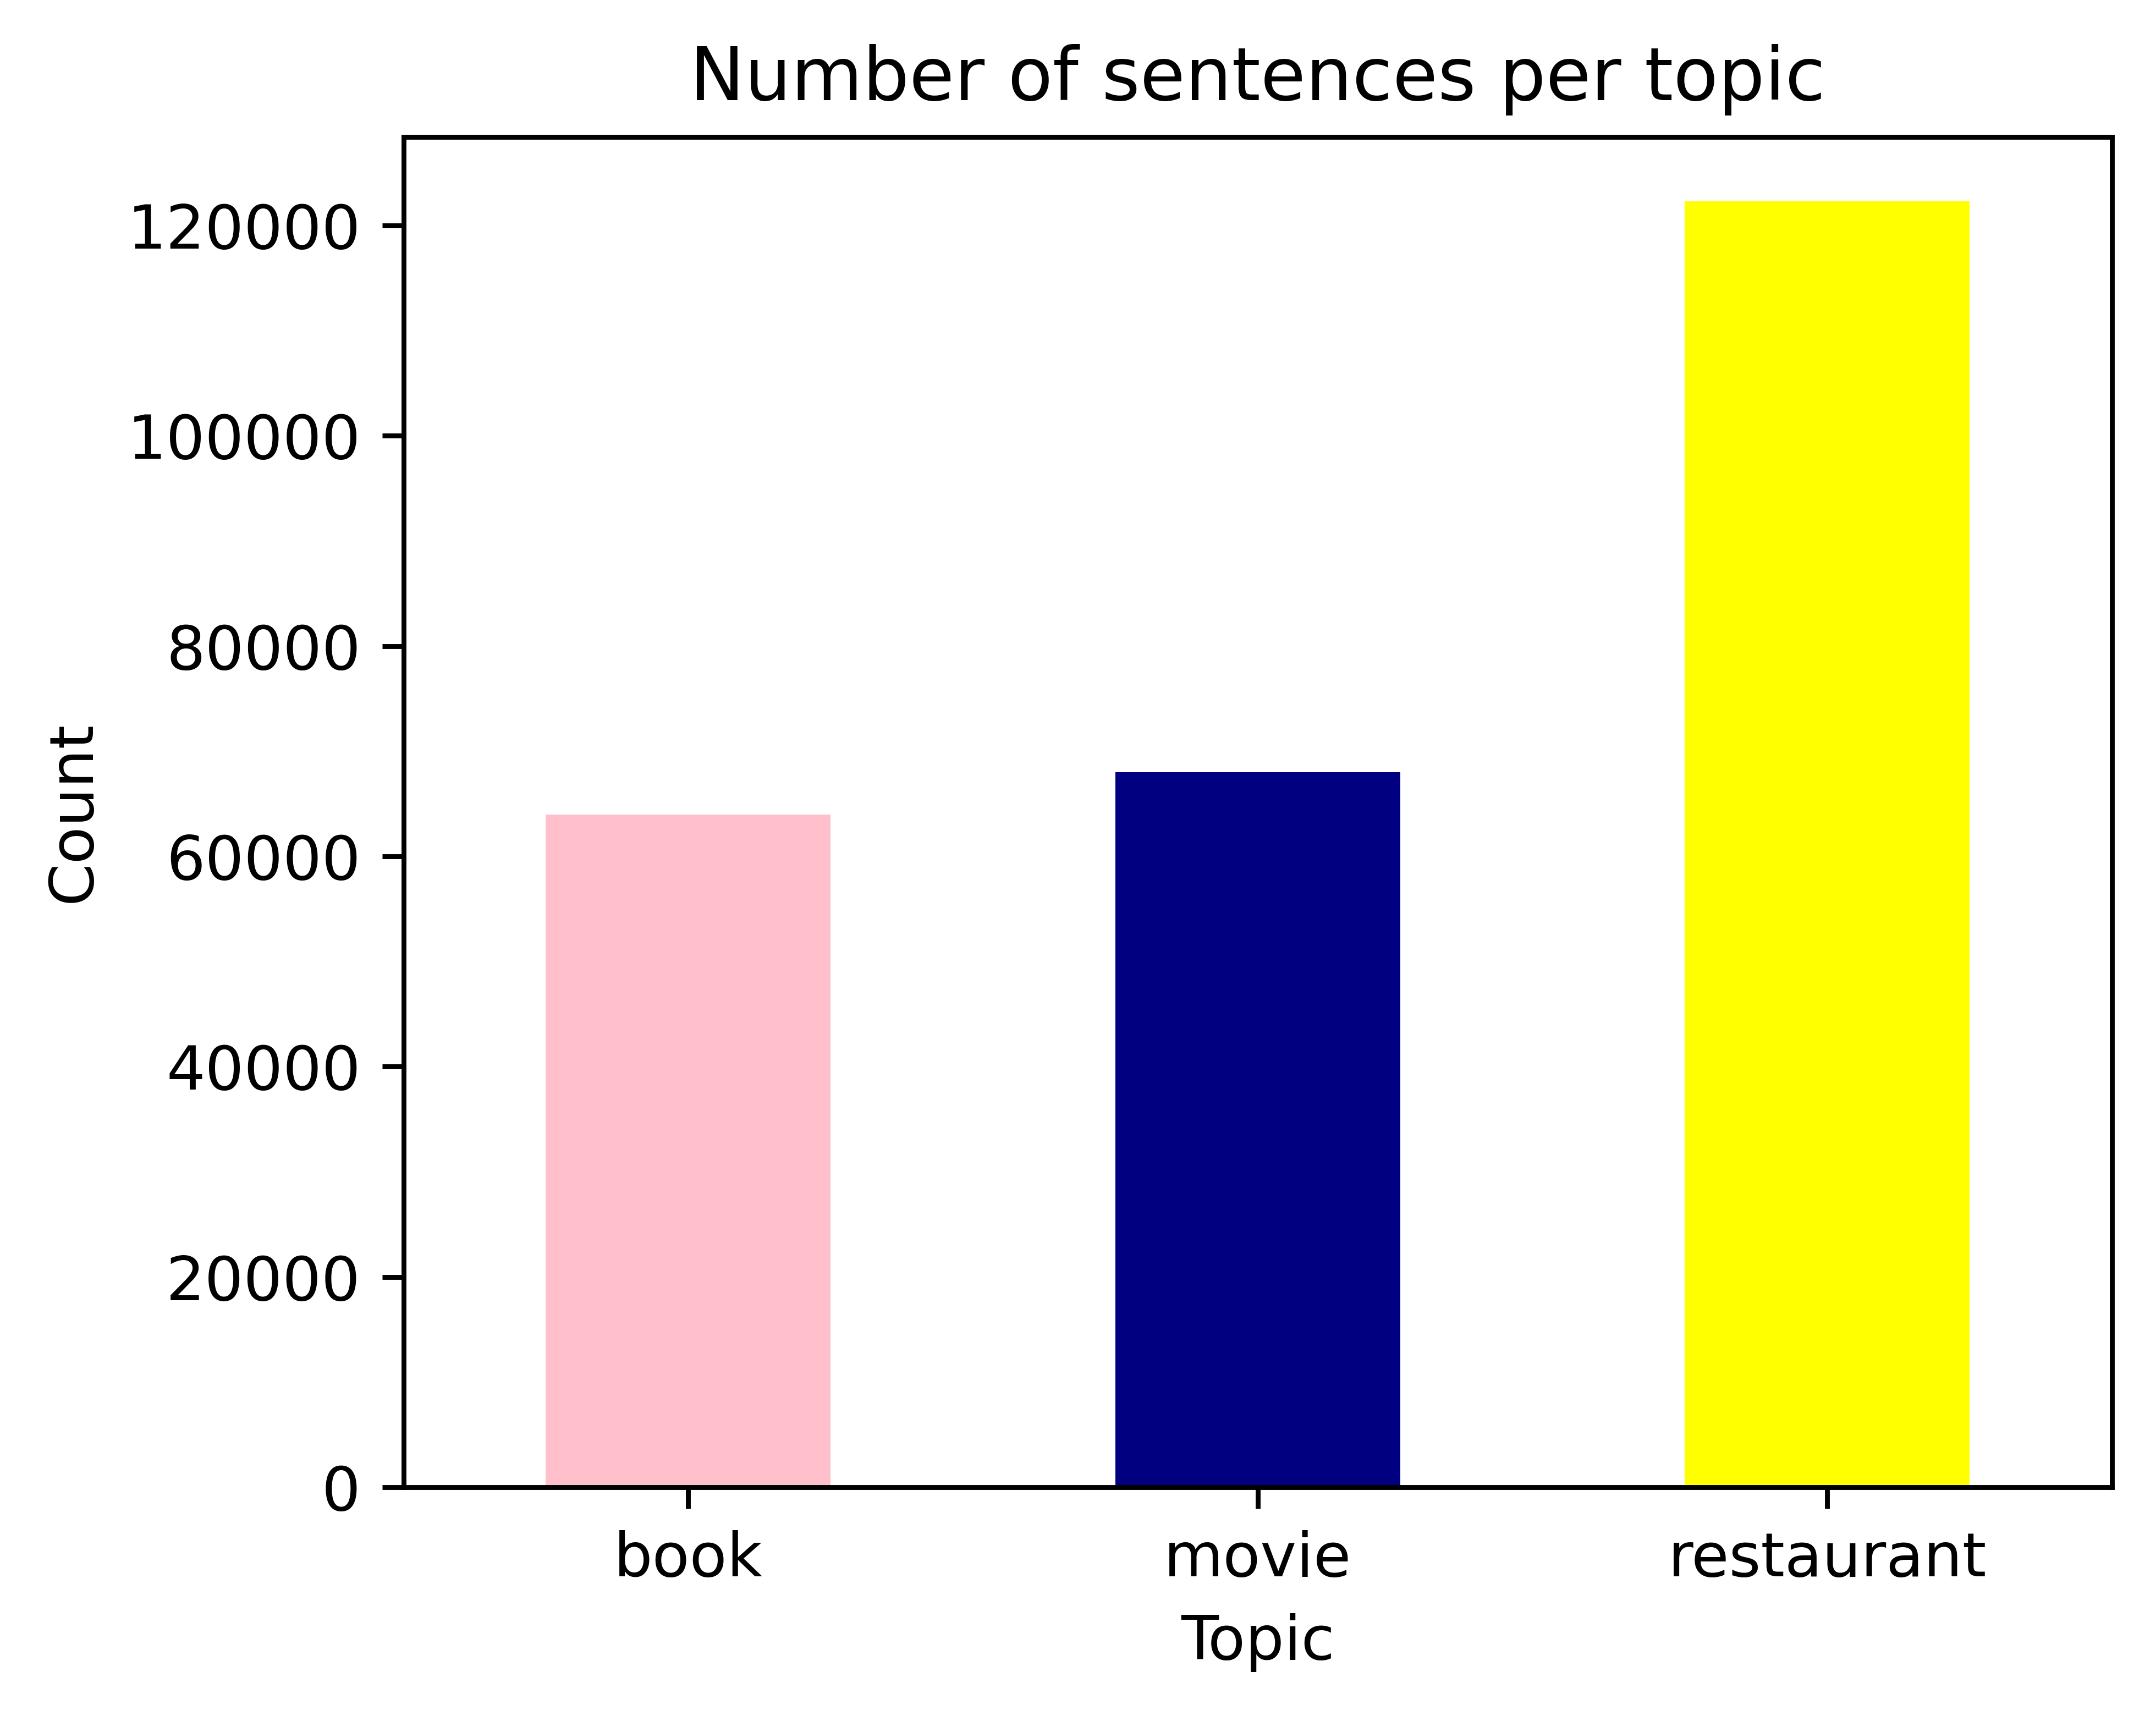

In [47]:
import matplotlib.pyplot as plt

topic_counts = df["domain"].value_counts().sort_index()

plt.figure(figsize=(5, 4), dpi=800)
topic_counts.plot(kind="bar", color=['pink', 'navy', 'yellow'])
plt.title("Number of sentences per topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

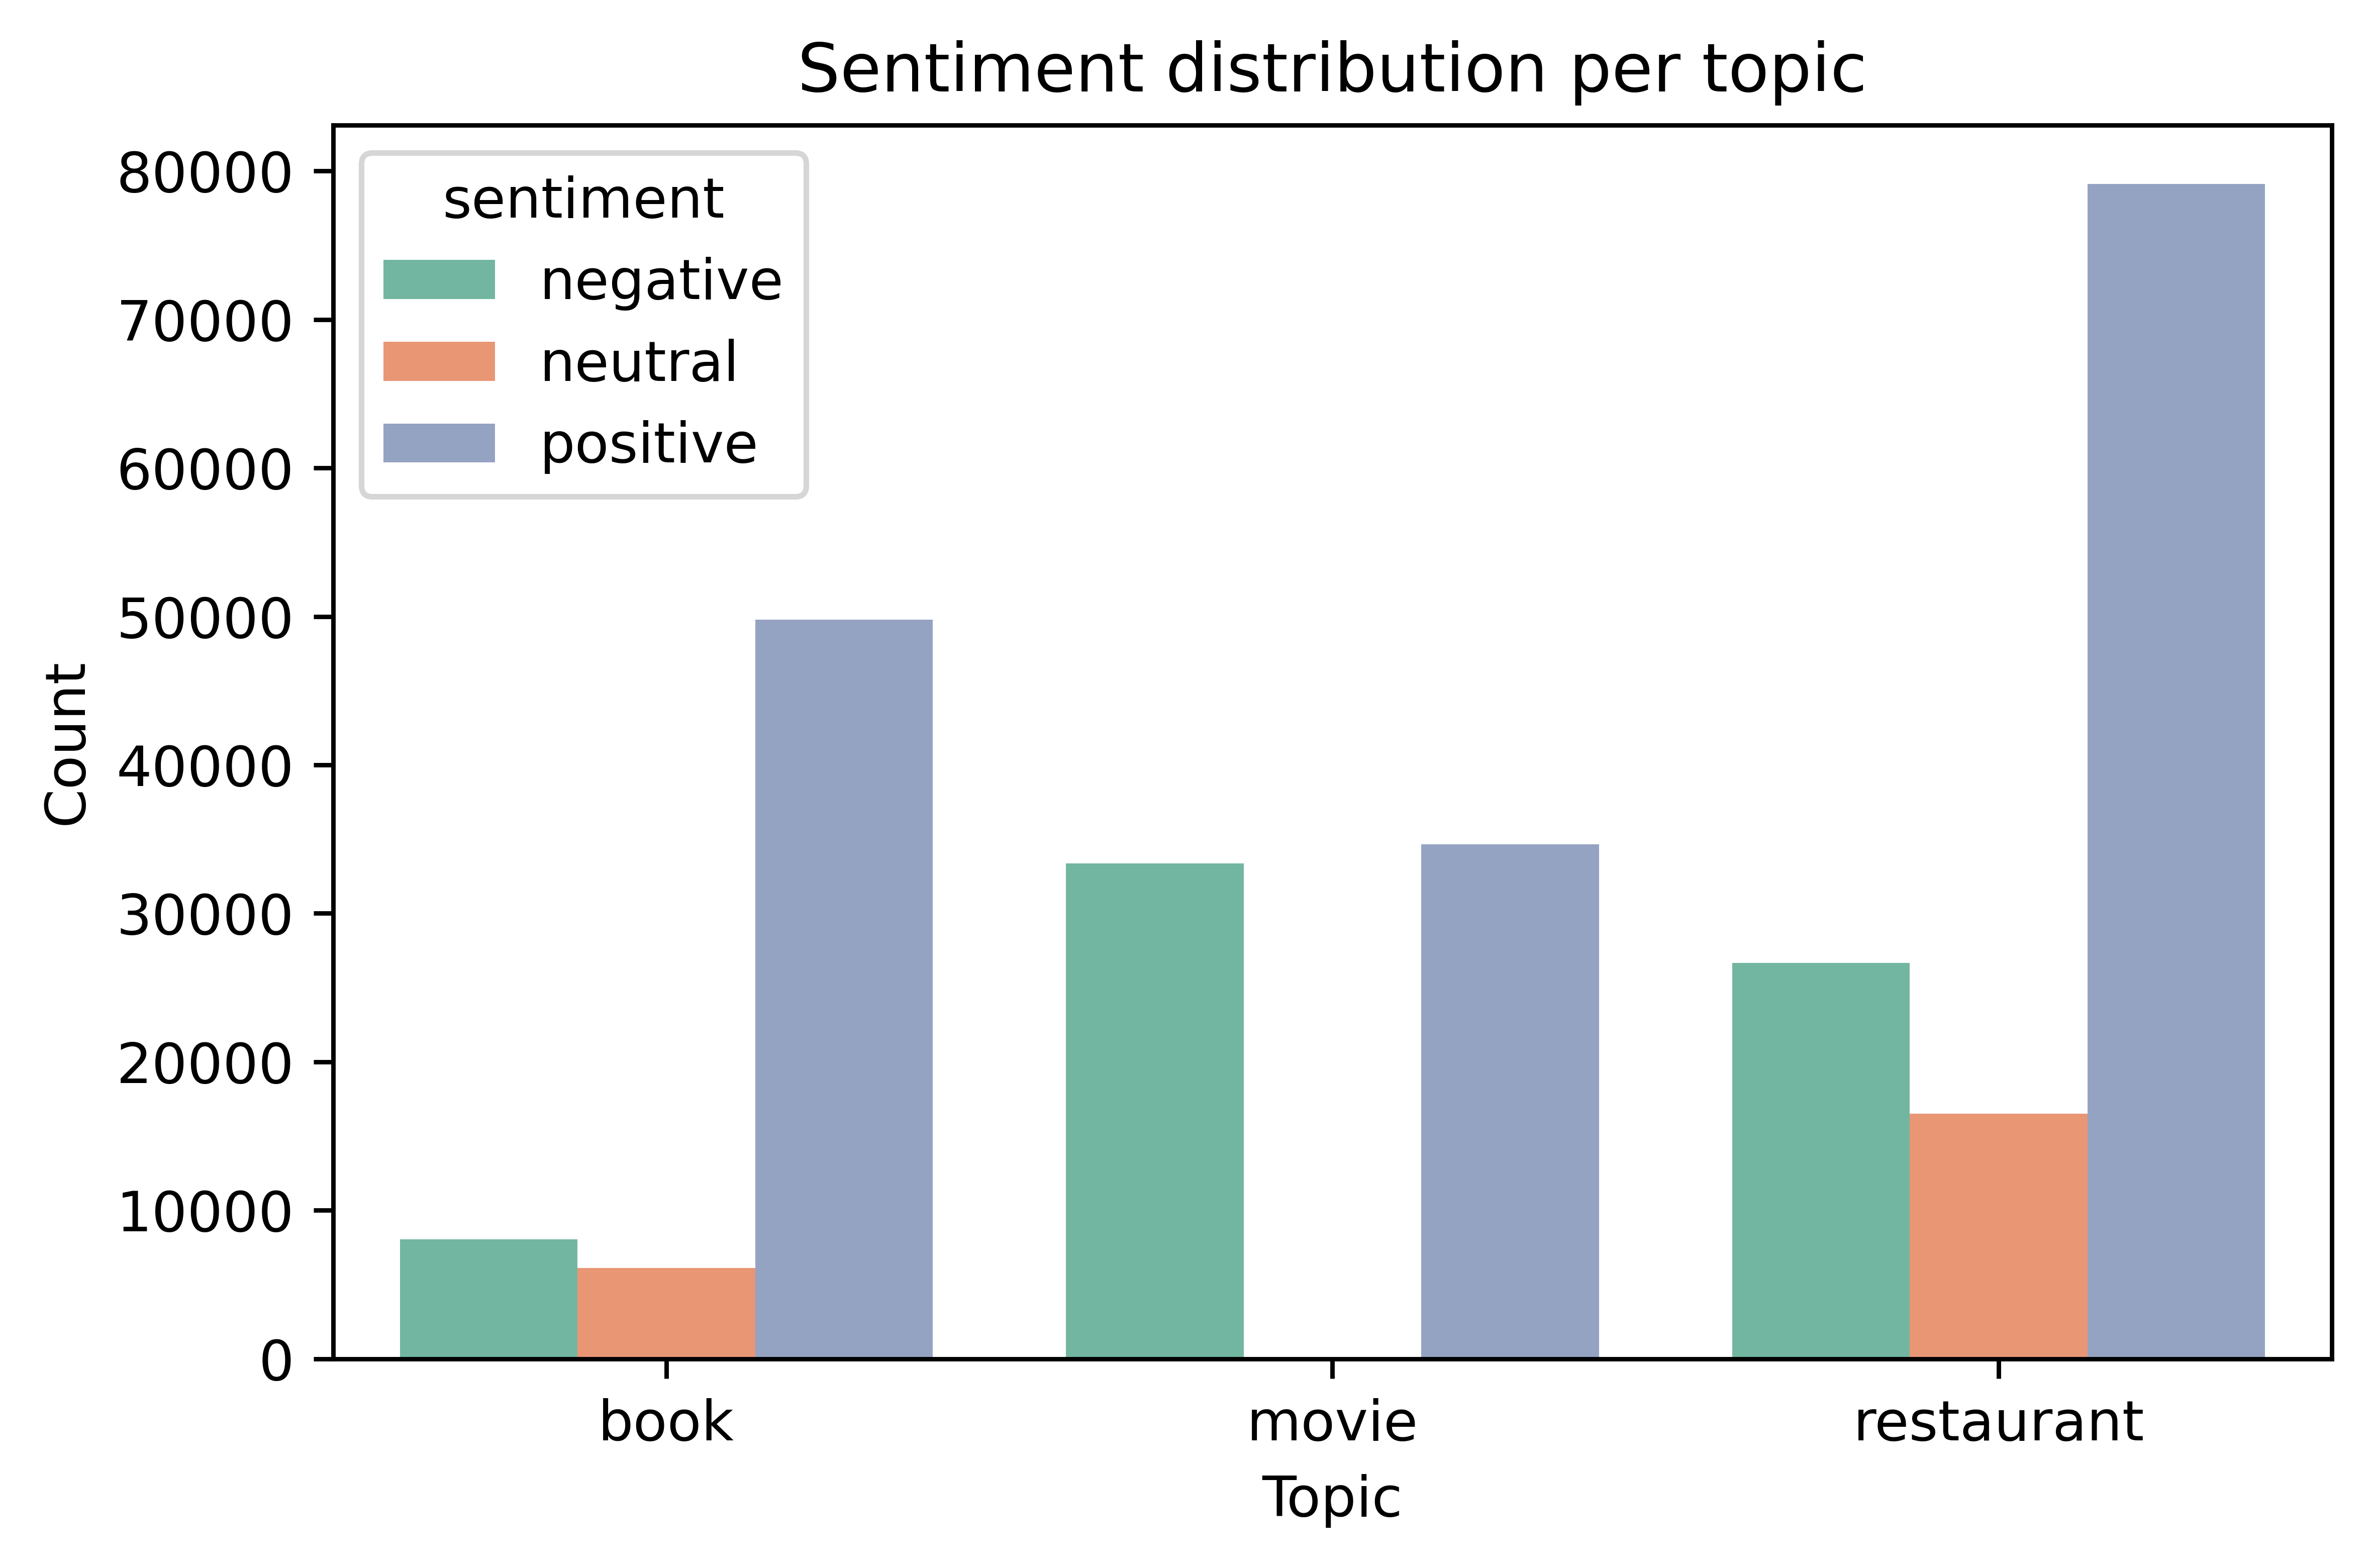

In [44]:
import seaborn as sns

sent_topic = (
    df.groupby(["domain", "sentiment"]).size().reset_index(name="count")
)

plt.figure(figsize=(6, 4), dpi=800)
sns.barplot(
    data=sent_topic,
    x="domain",
    y="count",
    hue="sentiment",
    palette="Set2"
)
plt.title("Sentiment distribution per topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\mboga\AppData\Local\Temp\ipykernel_21536\3834021717.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


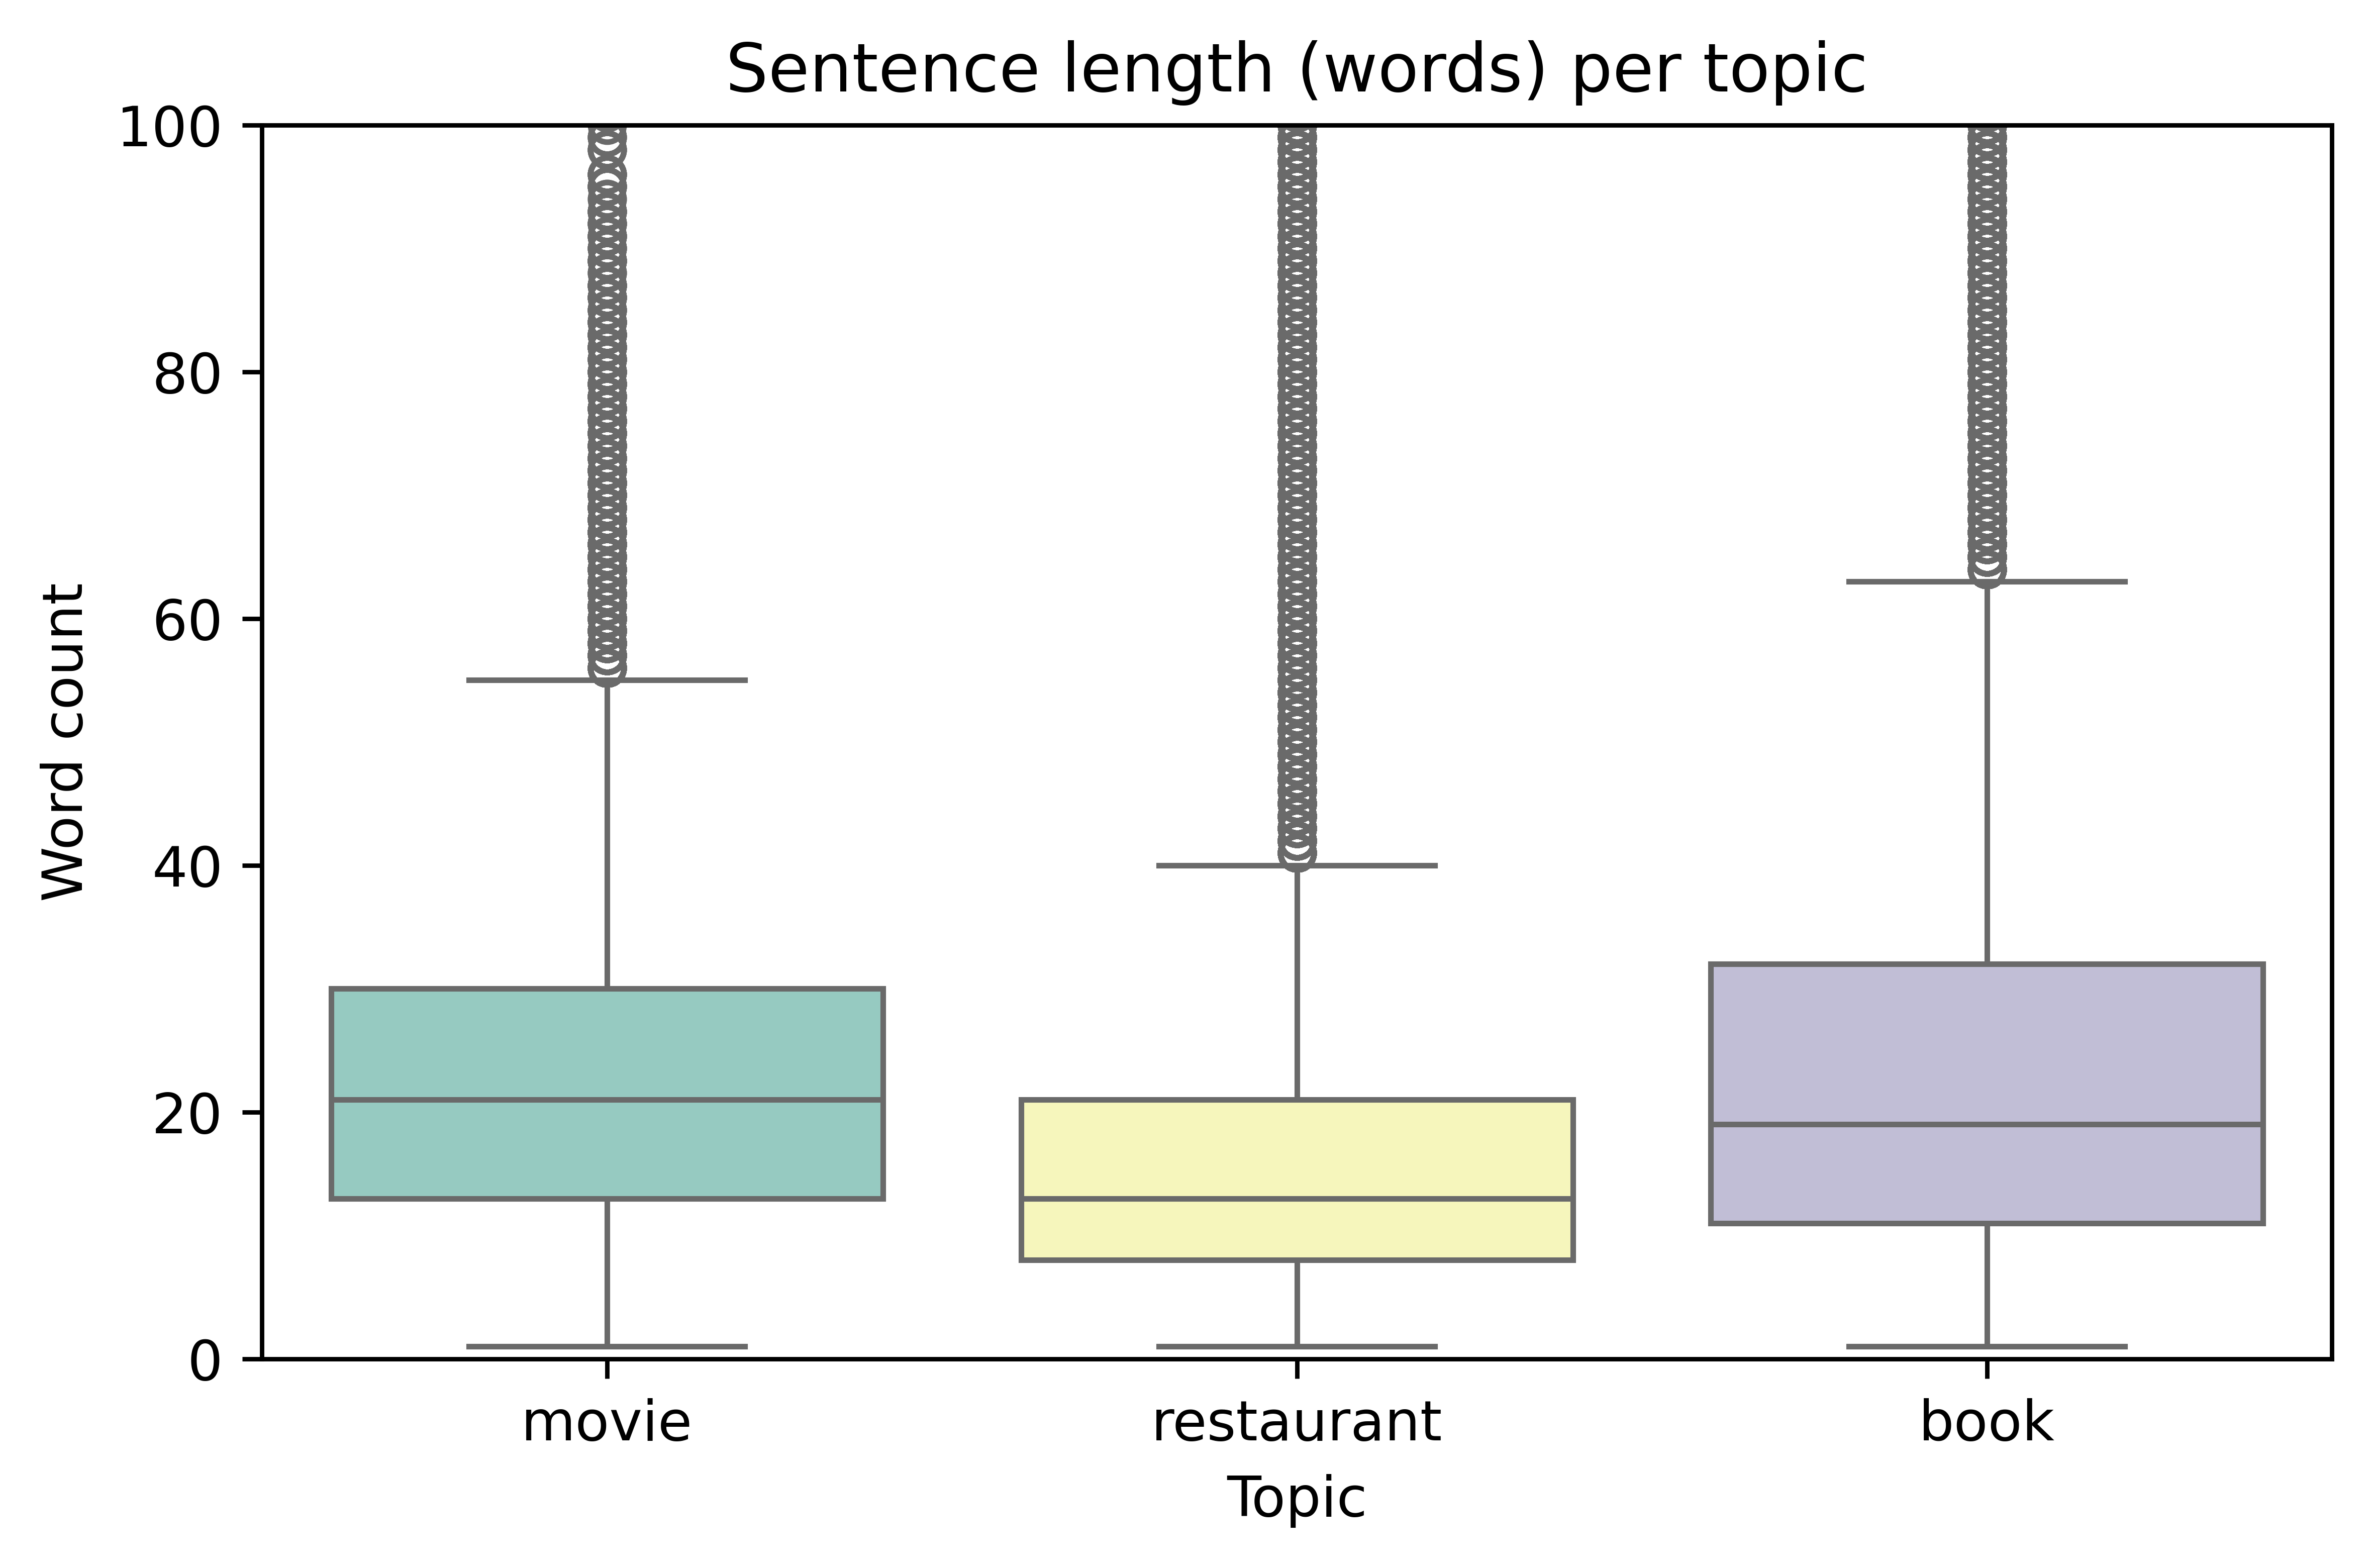

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

df_len = df.copy()
df_len["word_count"] = df_len["text"].astype(str).str.split().str.len()

plt.figure(figsize=(6, 4), dpi=800)
sns.boxplot(
    data=df_len,
    x="domain",
    y="word_count",
    palette="Set3"
)
plt.title("Sentence length (words) per topic")
plt.xlabel("Topic")
plt.ylabel("Word count")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()